<a href="https://colab.research.google.com/github/chrishg23-jpg/Community-Development-Framework/blob/main/N100back2begining2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

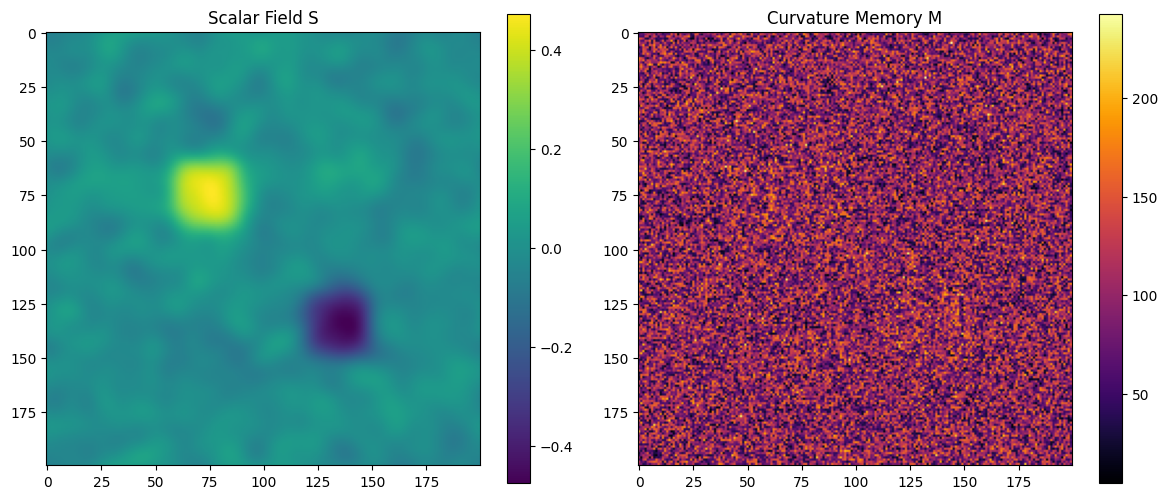

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parameters
# =========================
Nx, Ny = 200, 200
dx = dy = 1.0

dt = 0.01
steps = 2000

alpha = 0.6      # anti-diffusion (curvature creation)
beta  = 0.005    # damping (stability)
gamma = 0.0001   # global constraint (balance)

# =========================
# Fields
# =========================
S = np.random.uniform(-1, 1, (Nx, Ny))
M = np.zeros_like(S)   # curvature memory

# Seed asymmetry (same idea as your 3D pockets)
S[60:90, 60:90] += 0.5
S[120:150, 120:150] -= 0.5

# =========================
# Laplacian operator
# =========================
def laplacian(S):
    return (
        np.roll(S, 1, axis=0) + np.roll(S, -1, axis=0) +
        np.roll(S, 1, axis=1) + np.roll(S, -1, axis=1) -
        4 * S
    )

# =========================
# Time evolution
# =========================
for step in range(steps):
    lap = laplacian(S)
    global_mean = np.mean(S)

    # Core curvature engine
    dSdt = alpha * lap - beta * S - gamma * global_mean
    S += dt * dSdt

    # Curvature memory
    M += np.abs(lap)

# =========================
# Visualization
# =========================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(S, cmap='viridis')
plt.title("Scalar Field S")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(M, cmap='inferno')
plt.title("Curvature Memory M")
plt.colorbar()

plt.tight_layout()
plt.show()
